In [1]:
import os
import time
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
import MGLensing
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy import integrate
from copy import deepcopy


import pyccl as ccl

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

PyHMCode not installed!
PyHMCode not installed!
euclidlib not installed! Euclid TR1 setup will not be available!
/Users/s2265800/Desktop/GitHub/MGlensing/MGLensing


In [2]:
# switch to the main directory
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')

# Survey
LSST Y1 setup

In [3]:
MGL = MGLensing.MGL("ini_files/config_files/config_hmcode.yaml")
zz = MGL.Survey.zz_integr
nbin = MGL.Survey.nbin_s


l_wl_max, l_gc_max = MGL.Survey.ells_wl_max, MGL.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL.Survey.l_wl, MGL.Survey.l_gc, MGL.Survey.l_xc


Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  0
initialising hmcode


Zennaro 2024 cross-sqrt-bar boost is applied with self.flag_cross_sqrt_bar_boost:  False
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  375
gc_masked_ells:  272
xc_masked_ells:  451
3x2pt_masked_ells:  1098
computing data covariance


cov_flat:  (1650, 1650)
cov_flat_masked:  (1098, 1098)
managed to do cholesky decomposition
######CHOLESKY!!!!########
finish computing mock data
################################
model["nl_model"] =  0
initialising hmcode
Zennaro 2024 cross-sqrt-bar boost is applied with self.flag_cross_sqrt_bar_boost:  False
################################
checking parameters for theory....
all good with the model parameters
################################


# Cosmology
LCDM, no neutrinos, HMcode2020

In [4]:
params = {
    'Omega_m' :  0.315,
    'Omega_c' :  0.315-0.05,
    'Omega_cb' :  0.315,
    'Omega_nu':  0.,
    'As'      :  np.exp(3.07)*1.e-10,
    'Omega_b' :  0.05,
    'ns'      :  0.96,
    'h'       :  0.67,
    'Mnu'     :  0.0,
    'w0'      :  -1.0,
    'wa'      :  0.0,
    'a1_IA': 0.16,
    'eta1_IA': 1.66,
    'beta_IA': 0.,
}
b0 = 0.68
bias1_arr = np.array([b0*(1.+z_bin_center_i) for z_bin_center_i in MGL.Survey.z_bin_center_l ])
for bin_i in range(nbin):
    params[f'b1_{bin_i+1}']=bias1_arr[bin_i]

# Power spectrum comparison

In [5]:
# first call MGL
NL_MODEL_HMCODE = 0
NL_MODEL_BACCO = 1

NO_BARYONS = 0
BARYONS_HMCODE = 1
BARYONS_BCEMU = 2
BARYONS_BACCO = 3

BIAS_LIN = 0
BIAS_B1B2 = 1
BIAS_HEFT = 2

model_opt = {'nl_model': NL_MODEL_HMCODE, 'bias_model': BIAS_LIN, 'ia_model': 0, 'baryon_model': NO_BARYONS, 'photoz_err_model': 0.}
k_ell, mgl_pmm, mgl_pgm, mgl_pgg = MGL.get_power_spectra(params, model_opt)

model["nl_model"] =  0
initialising hmcode


In [6]:
# now call ccl
cosmo = ccl.Cosmology(h = params['h'],
                      Omega_c = params['Omega_c'],
                      Omega_b = params['Omega_b'],
                      m_nu = 0.,
                      Neff = 3.044, 
                      w0 = -1.,
                      wa = 0.,
                      Omega_k = 0.,
                      n_s = params['ns'], 
                      A_s = params['As'],
                      matter_power_spectrum = 'camb', # linear / halofit / camb ...
                      extra_parameters = {'camb':{"halofit_version": 'mead2020'}}, #    "HMCode_logT_AGN": 7.8} })
                      transfer_function='boltzmann_camb', # bbks / boltmann_class/_camb ...
                      T_ncdm=0
                      )

pk_values_ccl = ccl.boltzmann.get_camb_pk_lin(cosmo, nonlin=True ) 


In [7]:
_, rcom = MGL.get_expansion_and_rcom(params)
# pick 3 redshifts
z_int_pick = [60, 100, 120] #goes from 0 to 399
def k2ell(x, ind=z_int_pick[0]):
    return x*rcom[ind]-0.5
def ell2k(x, ind=z_int_pick[0]):
    return (x+0.5)/rcom[ind]
def k2ell1(x, ind=z_int_pick[1]):
    return x*rcom[ind]-0.5
def ell2k1(x, ind=z_int_pick[1]):
    return (x+0.5)/rcom[ind]
def k2ell2(x, ind=z_int_pick[2]):
    return x*rcom[ind]-0.5
def ell2k2(x, ind=z_int_pick[2]):
    return (x+0.5)/rcom[ind]
f_arr = [k2ell, k2ell1, k2ell2]
f_inv_arr = [ell2k, ell2k1, ell2k2]
# pick the bins
bin_i=2
bin_j=3

  ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='lower left', frameon=True, title_fontsize=18)



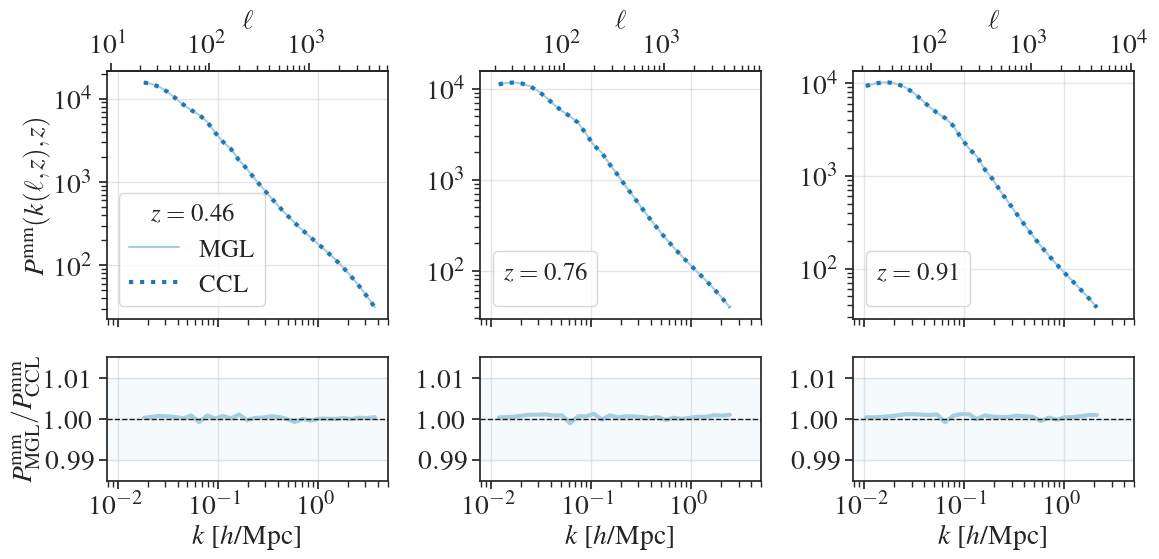

In [8]:

fig, ax = plt.subplots(2, 3, figsize=(12, 6), facecolor='w', gridspec_kw={'height_ratios':[2,1] }, sharex=True)
for i in range(3):
    ax[0][i].loglog(k_ell[:, z_int_pick[i]], mgl_pmm[:, z_int_pick[i]], linewidth=1.5, label='MGL' if i == 0 else '')
    # (k, a)
    ccl_pmm = pk_values_ccl[1](k_ell[:, z_int_pick[i]]*params['h'], 1./(1.+zz[z_int_pick[i]]))  * params['h']**3
    ax[0][i].loglog(k_ell[:, z_int_pick[i]], ccl_pmm, label='CCL' if i == 0 else '', ls=':')
    ax[1][i].semilogx(k_ell[:, z_int_pick[i]], mgl_pmm[:, z_int_pick[i]]/ccl_pmm)
    ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='lower left', frameon=True, title_fontsize=18)
    ax[1][i].set_xlabel("$k$ [$h$/Mpc]")
    secax = ax[0][i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')
    ax[0][i].grid(alpha=0.5)
    ax[1][i].grid(alpha=0.5)
    ax[1][i].axhspan(0.99, 1.01, color='C0', alpha=0.1, label='_nolegend_')
    ax[1][i].set_ylim(0.985, 1.015) 
    ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0][0].set_ylabel("$P^{\\rm mm}(k(\ell, z), z)$")
ax[1][0].set_ylabel("$P^{\\rm mm}_{\\rm MGL}/P_{\\rm CCL}^{\\rm mm}$")
plt.tight_layout()

# Redshift distribution and kernels

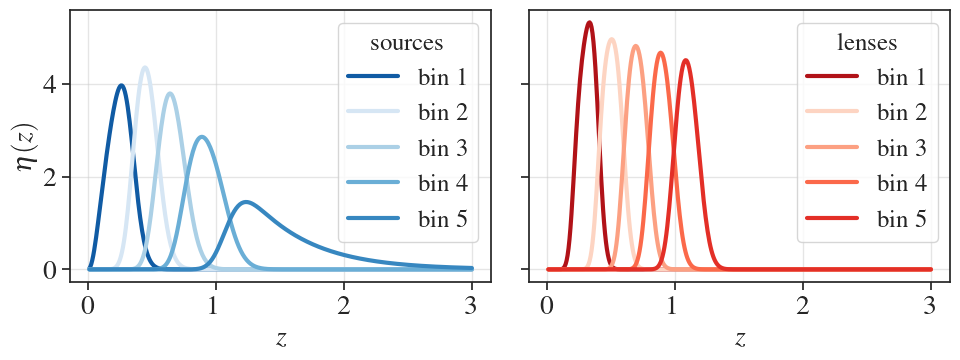

In [9]:
etaz = [MGL.Survey.eta_z_s, MGL.Survey.eta_z_l]
titles = ['sources', 'lenses']
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for k in range(2):
    for i in range(etaz[k].shape[1]):
        ax[k].plot(zz, etaz[k][:, i], label='bin ' + str(i + 1), color=sns.color_palette("Blues", 5)[i-1] if k==0 else sns.color_palette("Reds", 5)[i-1])
    ax[k].set_xlabel("$z$")
    ax[k].legend(loc='upper right', title=titles[k], title_fontsize=18)
    ax[k].grid(alpha=0.5)
ax[0].set_ylabel("$\\eta(z)$")
plt.tight_layout()

In [10]:
# tracers
lenses = [] 
# conversion factor due to differences in the definition of the IA bias in MGL and CCL
bias_ia = params['a1_IA']*(1.+zz)**params['eta1_IA']*0.0134/0.01387684609 
sources = []
for i in range(nbin):
    sources.append(ccl.WeakLensingTracer(cosmo, dndz=(zz, MGL.Survey.eta_z_s[:,i]),ia_bias=(zz,bias_ia))) #CCL automatically normalizes dNdz
    bias_gal = bias1_arr[i]*np.ones(len(zz))
    lenses.append(ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(zz, MGL.Survey.eta_z_l[:,i]), bias=(zz, bias_gal)))

In [11]:
W_WL, W_IA, W_GC = MGL.get_windows(params, model_opt)

model["nl_model"] =  0
initialising hmcode


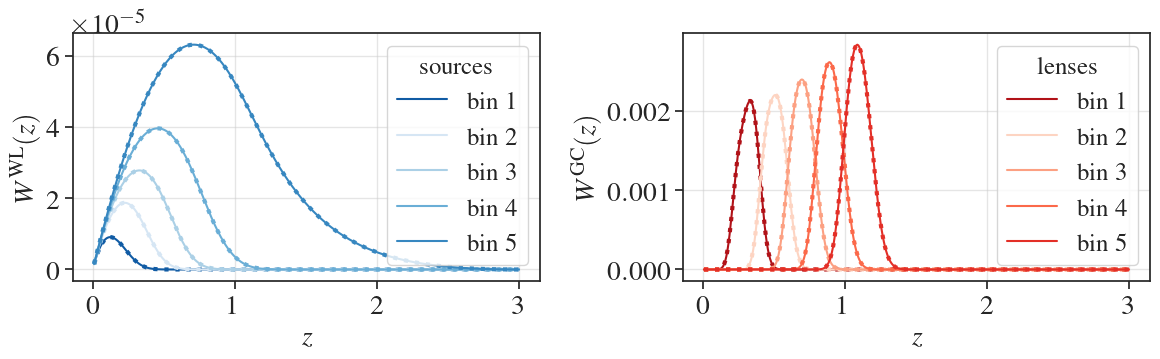

In [12]:
titles = ['sources', 'lenses']
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for k in range(2):
    for i in range(etaz[k].shape[1]):
        if k==0:
            ax[k].plot(zz, W_WL[0, :, i], label='bin ' + str(i + 1), color=sns.color_palette("Blues", 5)[i-1],linewidth=1.5)
            ax[k].plot(zz, sources[i].get_kernel(rcom/params['h'])[0]/params['h'], color=sns.color_palette("Blues", 5)[i-1], ls=':')
        else:
            ax[k].plot(zz, W_GC[0 ,:, i], label='bin ' + str(i + 1), color=sns.color_palette("Reds", 5)[i-1],linewidth=1.5)
            ax[k].plot(zz, lenses[i].get_kernel(rcom/params['h'])[0]/params['h'], color=sns.color_palette("Reds", 5)[i-1], ls=':')        
    ax[k].set_xlabel("$z$")
    ax[k].grid(alpha=0.5)
    ax[k].legend(loc='upper right', title=titles[k], title_fontsize=18)
ax[0].set_ylabel("$W^{\\rm WL}(z)$")
ax[1].set_ylabel("$W^{\\rm GC}(z)$")
plt.tight_layout()

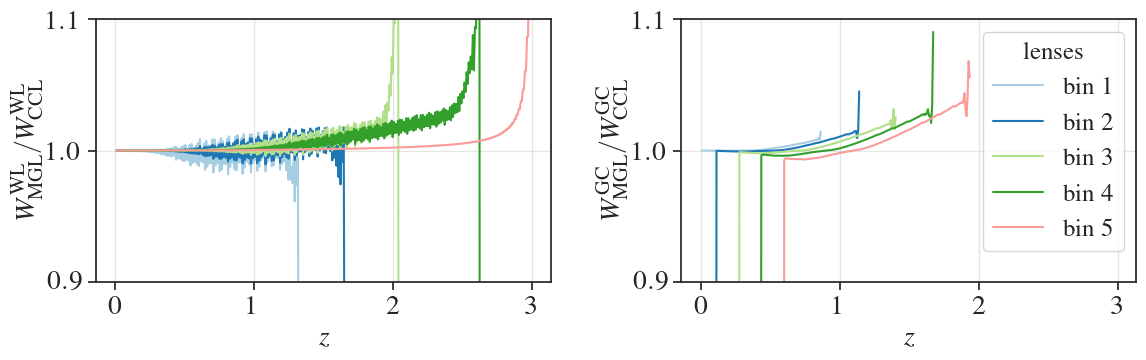

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for k in range(2):
    for i in range(etaz[k].shape[1]):
        if k==0:
            ax[k].plot(zz, W_WL[0, :, i]/(sources[i].get_kernel(rcom/params['h'])[0]/params['h']), label='bin ' + str(i + 1), linewidth=1.5)
            
        else:
            ax[k].plot(zz, W_GC[0 ,:, i]/(lenses[i].get_kernel(rcom/params['h'])[0]/params['h']), label='bin ' + str(i + 1), linewidth=1.5)       
    ax[k].set_xlabel("$z$")
    ax[k].grid(alpha=0.5)
    ax[k].set_ylim(0.9, 1.1)
ax[1].legend(loc='upper right', title=titles[k], title_fontsize=18)
ax[0].set_ylabel("$W^{\\rm WL}_{\\rm MGL}/W^{\\rm WL}_{\\rm CCL}$")
ax[1].set_ylabel("$W^{\\rm GC}_{\\rm MGL}/W^{\\rm GC}_{\\rm CCL}$")
plt.tight_layout()

# Angular power spectra

In [14]:
cl_ll_ccl_nl = np.zeros((nbin, nbin, len(l_wl)))
cl_gg_ccl_nl = np.zeros((nbin, nbin, len(l_gc)))
cl_lg_ccl_nl = np.zeros((nbin, nbin, len(l_xc)))
# calculate CCL Cls
for i in range(nbin):
    for j in range(nbin):
        cl_ll_ccl_nl[i,j] = ccl.angular_cl(cosmo, sources[i], sources[j], l_wl) 
        cl_gg_ccl_nl[i,j] = ccl.angular_cl(cosmo, lenses[i], lenses[j], l_gc) 
        cl_lg_ccl_nl[i,j] = ccl.angular_cl(cosmo, sources[i], lenses[j], l_xc) 



# add noise 
for i in range(nbin):
    cl_ll_ccl_nl[i,i] += MGL.Survey.noise['LL']
    cl_gg_ccl_nl[i,i] += MGL.Survey.noise['GG']

In [15]:
cl_ll_mgl, cl_gg_mgl, cl_lg_mgl, cl_gl_mgl =  MGL.get_c_ells(params, model_opt)

model["nl_model"] =  0
initialising hmcode
Theo model:  {'nl_model': 0, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}


In [16]:
prefactor_wl = \
            (np.sqrt((l_wl + 2.0) * (l_wl + 1.0) * l_wl * (l_wl - 1.0)) /
             (l_wl + 0.5) ** 2)

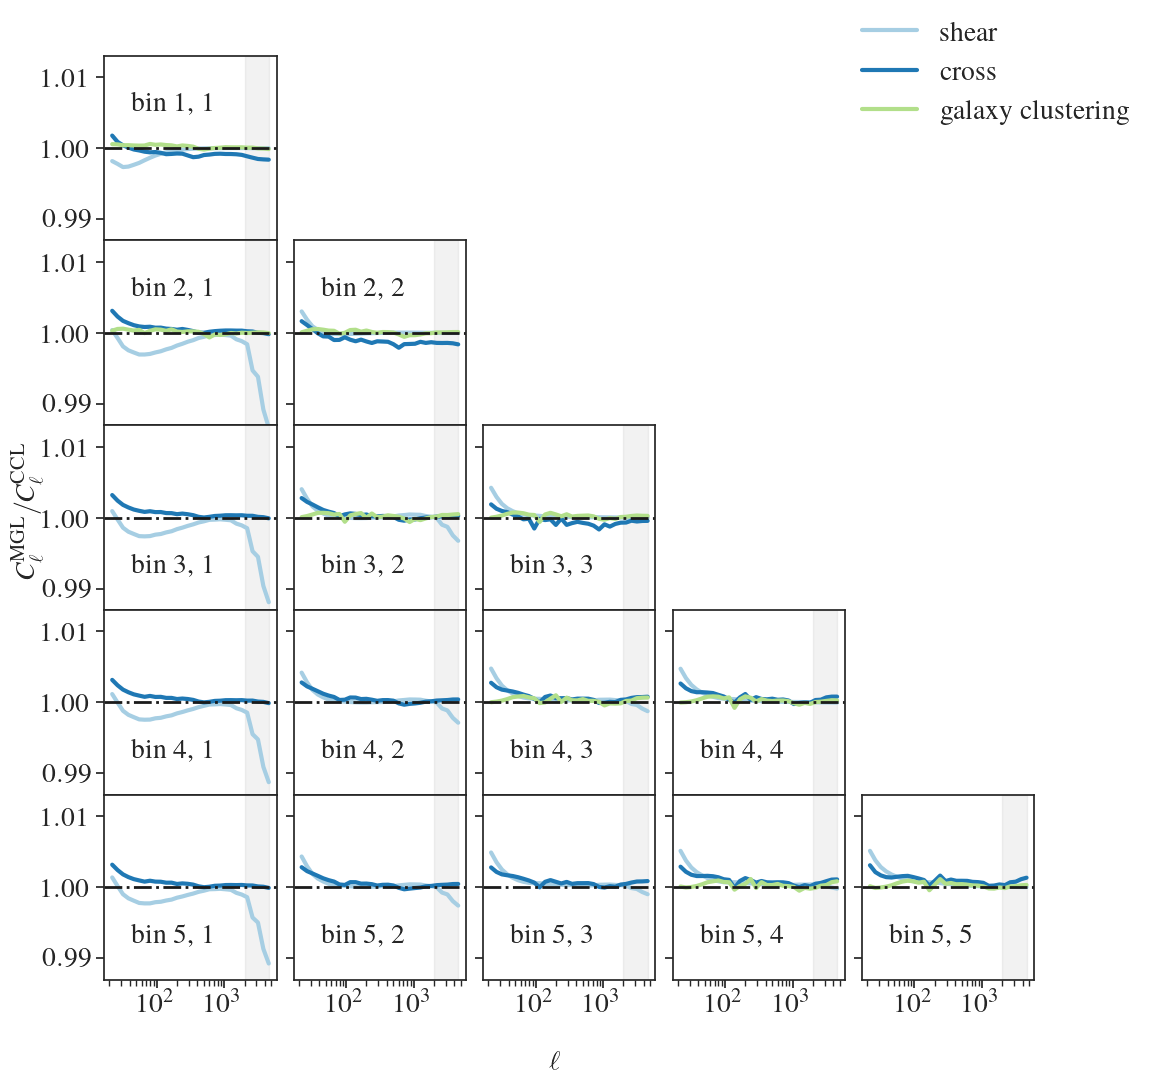

In [17]:

fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i,j].semilogx(l_wl, cl_ll_mgl[:,i,j]/cl_ll_ccl_nl[i, j, :])
            ax[i,j].semilogx(l_xc, cl_lg_mgl[:,i,j]/cl_lg_ccl_nl[i, j, :])
            ax[i,j].semilogx(l_gc, cl_gg_mgl[:,i,j]/cl_gg_ccl_nl[i, j, :])
            ax[i, j].set_ylim(0.987, 1.013)
            #ax[i, j].set_ylim(0.955, 1.045)
            ax[i,j].text(.4, .7, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)  if i<2 else ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axhline(y=1, linestyle='-.', linewidth=2, color='k')
            ax[i, j].axvspan(xmin=l_wl_max[i, j], xmax=l_wl[-1], color='grey', alpha=0.1)
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm MGL}_\ell/C^{\rm CCL}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend(['shear', 'cross', 'galaxy clustering'], loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)

In [18]:
err_cl_ll, err_cl_gg, err_cl_gl = MGL.get_errorbars(params)

cov_flat:  (1650, 1650)
cov_flat_masked:  (1650, 1650)


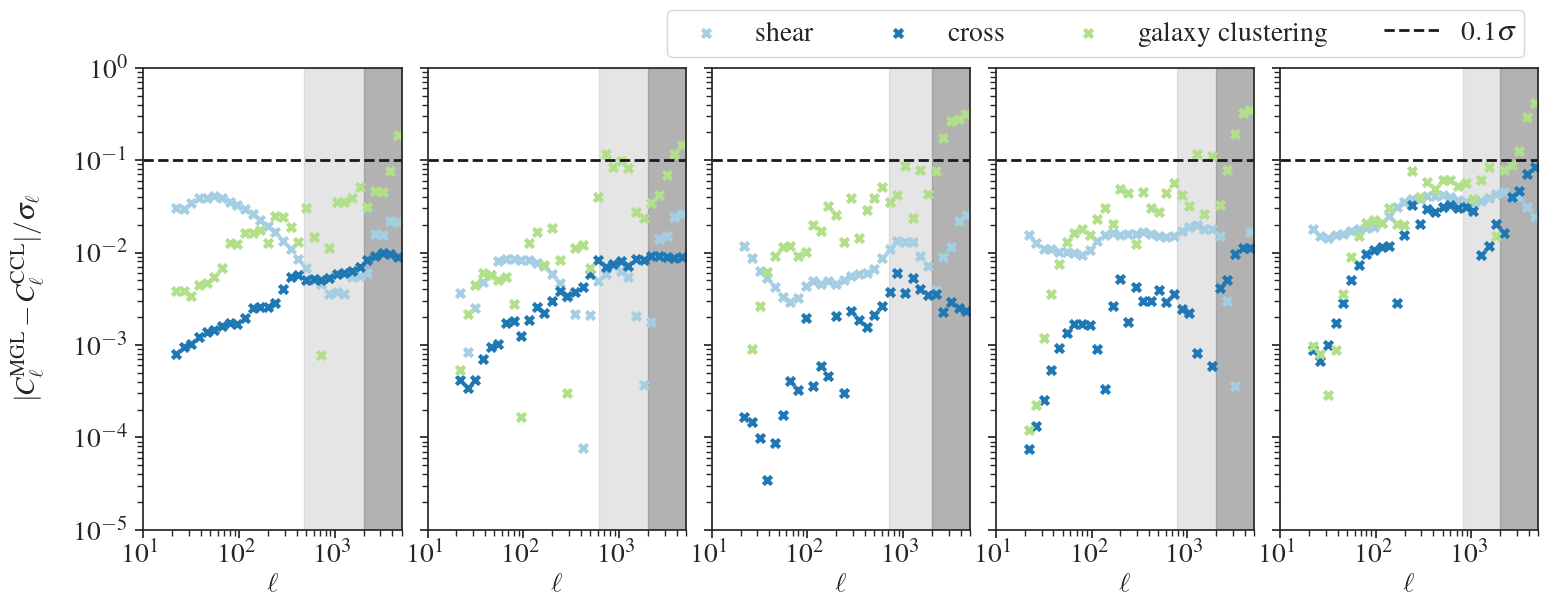

In [19]:
kmax07 = [478, 617, 716, 780, 818]
fig, ax = plt.subplots(1, nbin, figsize=(18, 6), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    ax[i].axvspan(5000, kmax07[i], color='grey', alpha=0.2, label='_nolegend_') #GG cuts  
    ax[i].axvspan(5000, 2000, color='grey', alpha=0.5, label='_nolegend_') 
    ax[i].scatter(l_wl, abs(prefactor_wl*cl_ll_mgl[:,i,i]-cl_ll_ccl_nl[i, i, :])/err_cl_ll[:, i, i], marker='x')
    ax[i].scatter(l_xc, abs(prefactor_wl*cl_lg_mgl[:,i,i]-cl_lg_ccl_nl[i, i, :])/err_cl_gl[:, i, i], marker='x')
    ax[i].scatter(l_gc, abs(cl_gg_mgl[:,i,i]-cl_gg_ccl_nl[i, i, :])/err_cl_gg[:, i, i], marker='x')
    ax[i].axhline(y=0.1, color='k', linestyle='--', linewidth=2)
    ax[i].set_ylim(0.00001, 1.)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlim(10, 5000)
    ax[i].set_xlabel(r'$\ell$', fontsize=20)
fig.text(0.06, 0.5, r'$|C^{\rm MGL}_\ell-C^{\rm CCL}_\ell|/\sigma_\ell$', ha='center', va='center', rotation='vertical', fontsize=20) 
fig.legend(['shear', 'cross', 'galaxy clustering', '$0.1 \sigma$'], loc='upper right', ncol=4, bbox_to_anchor=(0.9,1), bbox_transform=fig.transFigure, fontsize=20, frameon=True)